# 只交易 breakout，加入40% carry值得吗？

本报告对比纯 breakout、纯 carry、**40% carry＋60% breakout**。40%是规则家族的 forecast 权重；家族内部等权，混合后执行原生 forecast cap、持仓、buffer、整手与费用。

沿用当前组合报告的**1亿元人民币**本金、2026-09-07审核数据和16%风险目标。无单品种上限用来观察信号分散效果；20%单品种上限提供限仓敏感性。全部图表使用线性坐标。

先运行三策略×两档上限的6个主对照。再将混合策略的目标预先设为8%、12%、20%、24%，增加8个System，比较与breakout16接近的风险。**回撤相近定义为相差不超过2个百分点；Sharpe相近定义为相差不超过0.10。** 另列Sharpe至少达到基准减0.10的情形。若没有满足条件的点，直接报告未找到。网格结果属于全历史事后诊断，实际采用建议以固定16%主对照和分时期结果为依据。

数据有效区间与5%低波动筛选沿用全历史事后审理；早期品种少、弱成交历史与成交量容量问题会影响可实现性。本报告以三组共同输入资格隔离规则差异；目前breakout若使用更宽的品种范围，收益需另行核对。

## 已执行结果

同16%目标，加入40% carry相对纯breakout：

- **无上限：CAGR 18.02%→19.01%（+0.99个百分点/年），Sharpe 1.35→1.60，最大回撤19.32%→19.62%。**
- **单品种20%上限：CAGR 11.12%→10.99%（−0.13个百分点/年），Sharpe 1.11→1.35，最大回撤17.31%→13.16%。**
- 20%上限下，混合目标20%与24%的CAGR为12.54%和13.95%，相对breakout16增加1.42和2.82个百分点/年，回撤均在基准±2个百分点内。这是全历史事后风险匹配。

研究支持carry的分散价值，CAGR改善存在时期依赖。详细的纯carry对照、分时期表现、回撤阶段、样本不确定性和容量限制见后文结论。

In [20]:
%matplotlib inline
import gc
import hashlib
import logging
import time
import warnings
from copy import deepcopy
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits
from syscore.constants import arg_not_supplied
from syscore.dateutils import BUSINESS_DAYS_IN_YEAR
from sysdata.config.configdata import Config
from sysdata.data_blob import dataBlob
from sysdata.sim.db_futures_sim_data import dbFuturesSimData, use_sim_classes
from sysobjects.adjusted_prices import futuresAdjustedPrices
from sysobjects.multiple_prices import futuresMultiplePrices
from systems.accounts.curves.account_curve import accountCurve
from systems.accounts.pandl_calculators.pandl_calculation_dict import pandlCalculationWithoutPositions
from syslogging.logger import get_logger

get_logger('carry40_comparison')
logging.getLogger().setLevel(logging.WARNING)
threadpool_limits(limits=1)
PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/'sysdata').is_dir() and (p/'examples/chinese_futures').is_dir())
RESEARCH_CONFIG = PROJECT/'examples/chinese_futures/config'
AUDIT_ROOT = PROJECT/'private/research_runs/carry_breakout_native_2026-09-07'
DATA_ROOT = AUDIT_ROOT/'v2_inputs'
WORK_PARQUET = DATA_ROOT/'parquet'
RUN_ROOT = AUDIT_ROOT/'carry40_comparison'
RUN_ROOT.mkdir(exist_ok=True)
(RUN_ROOT/'figures').mkdir(exist_ok=True)
AS_OF = '2026-09-07'
CUTOFF = pd.Timestamp(AS_OF) + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
CAPITAL, VOL_TARGET, ANNUAL_DAYS = 100_000_000., 16., BUSINESS_DAYS_IN_YEAR
CASES = ['breakout', 'carry', 'mixed40']
CAPS = {'unlimited': None, 'cap20': .20}
LABELS = {'breakout':'纯 breakout', 'carry':'纯 carry', 'mixed40':'40% carry + 60% breakout'}
CAP_LABELS = {'unlimited':'无单品种上限', 'cap20':'单品种20%上限'}
# 网格预先固定；只对40%混合检验风险目标，breakout16始终作为锚点。
TARGETS = {'breakout':[16.], 'carry':[16.], 'mixed40':[16., 8., 12., 20., 24.]}
mapping = pd.read_csv(PROJECT/'sysdata/tushare/config/futures_instruments.csv')
instruments = sorted(mapping.loc[mapping.StitchMode.eq('stitch'), 'Instrument'])
VOL_FLOOR_POINTS = pd.read_csv(RESEARCH_CONFIG/'vol_floor_points.csv', index_col='Instrument').vol_floor_points.to_dict()
trading_windows = pd.read_csv(DATA_ROOT/'trading_windows.csv', parse_dates=['Start','End']).dropna(subset=['Start','End'])
input_files = sorted(WORK_PARQUET.rglob('*.parquet')) + [DATA_ROOT/'trading_windows.csv', DATA_ROOT/'rollconfig.csv']
input_hashes = {str(p):hashlib.sha256(p.read_bytes()).hexdigest() for p in input_files}
pd.Series(input_hashes, name='sha256').to_csv(RUN_ROOT/'input_hashes.csv')
plt.style.use('default')
plt.rcParams.update({'font.family':'Arial Unicode MS', 'axes.grid':True, 'grid.alpha':.2, 'figure.dpi':110})
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format','{:,.3f}'.format)
assert len(instruments)==95 and ANNUAL_DAYS==256
print(f'数据截止 {AS_OF}；本金 {CAPITAL:,.0f} 元；14个独立System。')
assert (DATA_ROOT/'volume_diagnostics.parquet').is_file(), '需要2026-09-07冻结输入；准备方法见本目录README。'

数据截止 2026-09-07；本金 100,000,000 元；14个独立System。


## 固定参数与共同输入

carry：10/30/60/125日；breakout：40/80/160日。固定scalars、FDM=1、forecast cap=20、10%buffer、逐品种价格点波动率下限均沿用前一轮。IDM在各策略16%无上限System内按原生历史相关性估计，并供同策略各风险目标与限仓档复用；同日数据进入，未来数据不参与当日估计。

In [2]:
from sysdata.sim.db_futures_sim_data import use_sim_classes
from systems.basesystem import System
from systems.accounts.accounts_stage import Account
from systems.portfolio import Portfolios
from systems.positionsizing import PositionSizing
from systems.rawdata import RawData
from systems.forecast_combine import ForecastCombine
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecasting import Rules
from systems.system_cache import output, diagnostic
from systems.provided.rules.carry import carry
from systems.provided.rules.breakout import breakout
from sysquant.estimators.vol import mixed_vol_calc

class ResearchData(dbFuturesSimData):
    def __init__(self, windows=arg_not_supplied, end=None):
        self.cutoff = CUTOFF if end is None else pd.Timestamp(end)
        selected = trading_windows if windows is arg_not_supplied else windows
        super().__init__(data=dataBlob(class_list=list(use_sim_classes.values()),
                         parquet_store_path=str(WORK_PARQUET), log_name='portfolio_data',
                         csv_data_paths={'csvRollParametersData':str(DATA_ROOT),
                                         'csvFuturesInstrumentData':str(PROJECT/'data/futures/csvconfig')}),
                         trading_windows=arg_not_supplied if selected is None else selected)

    def get_backadjusted_futures_price(self, instrument_code):
        return futuresAdjustedPrices(super().get_backadjusted_futures_price(instrument_code).loc[:self.cutoff].copy())

    def get_multiple_prices_from_start_date(self, instrument_code, start_date):
        return futuresMultiplePrices(super().get_multiple_prices_from_start_date(instrument_code, start_date).loc[:self.cutoff].copy())

def warmed_breakout(price, lookback=80):
    return breakout(price, lookback=lookback).where(price.notna().cumsum() >= int(np.ceil(lookback / 2)))

class WindowRawData(RawData):
    @output()
    def daily_returns_volatility(self, instrument_code):
        return super().daily_returns_volatility(instrument_code).clip(lower=self.config.vol_floor_points[instrument_code])

RULES = {
    'carry10': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 10}},
    'carry30': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 30}},
    'carry60': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 60}},
    'carry125': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 125}},
    'breakout40': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 40}},
    'breakout80': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 80}},
    'breakout160': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 160}},
}
SCALARS = {'carry10': 27.815707053556984, 'carry30': 28.384062881349813,
           'carry60': 28.40072429176199, 'carry125': 29.366474500729886,
           'breakout40': .7036929411910525, 'breakout80': .726260784624834, 'breakout160': .7388310187414805}
WEIGHTS = {
    'carry': {'carry10': .25, 'carry30': .25, 'carry60': .25, 'carry125': .25},
    'breakout': {'breakout40': 1/3, 'breakout80': 1/3, 'breakout160': 1/3},
    'mixed40': {'carry10': .10, 'carry30': .10, 'carry60': .10, 'carry125': .10,
                'breakout40': .20, 'breakout80': .20, 'breakout160': .20},
}
BASE_CONFIG = {
    'forecast_scalars': SCALARS, 'forecast_cap': 20., 'forecast_div_multiplier': 1.,
    'use_forecast_scale_estimates': False, 'use_forecast_weight_estimates': False,
    'use_forecast_div_mult_estimates': False, 'forecast_weight_ewma_span': 1,
    'forecast_post_ceiling_cost_SR': 999999,
    'notional_trading_capital': CAPITAL, 'percentage_vol_target': VOL_TARGET, 'base_currency': 'CNH',
    'capital_multiplier': {'func': 'syscore.capital.full_compounding'},
    'instrument_div_multiplier': 1., 'instrument_weight_ewma_span': 1,
    'use_instrument_weight_estimates': False, 'use_instrument_div_mult_estimates': True,
    'instrument_correlation_estimate': {
        'func': 'sysquant.estimators.correlation_over_time.correlation_over_time_for_returns',
        'frequency': 'W', 'date_method': 'expanding', 'interval_frequency': 'W',
        'using_exponent': True, 'ew_lookback': 25, 'min_periods': 20,
        'cleaning': True, 'rollyears': 20, 'floor_at_zero': True, 'forward_fill_price_index': True,
    },
    'instrument_div_mult_estimate': {
        'func': 'sysquant.estimators.diversification_multipliers.diversification_multiplier_from_list',
        'ewma_span': 125, 'dm_max': 2.5,
    },
    'buffer_method': 'forecast', 'buffer_size': .10, 'buffer_trade_to_edge': True,
    'use_SR_costs': False, 'vol_normalise_currency_costs': False, 'multiply_roll_costs_by': .5,
    'volatility_calculation': {
        'func': 'sysquant.estimators.vol.mixed_vol_calc',
        'name_returns_attr_in_rawdata': 'daily_returns', 'multiplier_to_get_daily_vol': 1.,
        'days': 35, 'min_periods': 10, 'slow_vol_years': 20,
        'proportion_of_slow_vol': .35, 'vol_abs_min': 0., 'backfill': False,
    },
}
BASE_CONFIG['vol_floor_points'] = deepcopy(VOL_FLOOR_POINTS)
assert all(np.isclose(sum(w.values()), 1) for w in WEIGHTS.values())
display(pd.DataFrame(WEIGHTS).fillna(0).join(pd.Series(SCALARS, name='scalar')))

,carry,breakout,mixed40,scalar
carry10,0.250,0.000,0.100,27.816
carry30,0.250,0.000,0.100,28.384
carry60,0.250,0.000,0.100,28.401
carry125,0.250,0.000,0.100,29.366
breakout40,0.000,0.333,0.200,0.704
breakout80,0.000,0.333,0.200,0.726
breakout160,0.000,0.333,0.200,0.739


## 审核历史、逐区间预热与共同资格

108个审核区间分别计算价格差、波动率与规则。结束区间在经审核的最后报价平仓并计成本；恢复后重新预热。Carry缺失日表示已有PRICE报价但期限价差输入不足。三策略采用同日共同资格，未完成全部规则预热时保持现金。

In [3]:
# 每个审核区间使用独立的原生数据、波动率与规则阶段，恢复后重新预热。
data = ResearchData()
raw_data = ResearchData(windows=None)
metadata = raw_data.get_all_instrument_data_as_df().reindex(instruments)
market, raw_rule_frames, coverage_rows, window_rows = {}, {}, [], []
for code in instruments:
    complete = pd.DataFrame(raw_data.get_multiple_prices(code)).resample('B').last()
    full_index = complete.index
    pieces, forecasts = [], []
    intervals = trading_windows.loc[trading_windows.Instrument.eq(code)]
    for number, (_, window) in enumerate(intervals.iterrows(), 1):
        one_window = pd.DataFrame([window])
        cfg = Config(deepcopy(BASE_CONFIG))
        cfg.instruments = [code]
        cfg.trading_rules = deepcopy(RULES)
        local = System([WindowRawData(), Rules()], ResearchData(windows=one_window), cfg)
        multiple = pd.DataFrame(local.data.get_multiple_prices(code)).resample('B').last()
        if multiple.PRICE.count() == 0:
            local.data.data.close()
            continue
        adjusted = local.rawdata.get_daily_prices(code)
        returns = local.rawdata.daily_returns(code)
        raw_vol = mixed_vol_calc(returns, days=35, min_periods=10, slow_vol_years=20,
                                  proportion_of_slow_vol=.35, vol_abs_min=0., backfill=False)
        used_vol = local.rawdata.daily_returns_volatility(code)
        pd.testing.assert_series_equal(used_vol, raw_vol.clip(lower=VOL_FLOOR_POINTS[code]), check_names=False)
        price = multiple.PRICE.ffill()
        observed = multiple.PRICE.notna()
        valid_carry = (multiple.PRICE.notna() & multiple.CARRY.notna()
                       & multiple.PRICE_CONTRACT.notna() & multiple.CARRY_CONTRACT.notna()
                       & multiple.PRICE_CONTRACT.ne(multiple.CARRY_CONTRACT))
        # 交易所休市日沿用区间内的上一输入，实际缺失 carry 的报价日仍标记缺失。
        carry_available = valid_carry.where(observed).ffill().fillna(False).astype(bool)
        piece = pd.DataFrame({'price':price, 'adjusted_price':adjusted, 'returns':returns,
                    'observed':observed, 'raw_vol_points':raw_vol, 'used_vol_points':used_vol,
                    'raw_vol_pct':100*raw_vol/price.abs()*np.sqrt(ANNUAL_DAYS),
                    'used_vol_pct':100*used_vol/price.abs()*np.sqrt(ANNUAL_DAYS),
                    'carry_available':carry_available, 'window':number})
        raw = pd.concat({name:local.rules.get_raw_forecast(code,name) for name in RULES},axis=1)
        pieces.append(piece)
        forecasts.append(raw)
        window_rows.append({'instrument':code,'window':number,'start':piece.index.min(),
            'end':piece.index.max(),'observed_days':int(observed.sum()),
            'first_all_rules':raw.dropna().index.min(),'first_vol':raw_vol.first_valid_index()})
        local.data.data.close()
    columns = ['price','adjusted_price','returns','observed','raw_vol_points','used_vol_points',
               'raw_vol_pct','used_vol_pct','carry_available','window']
    frame = pd.concat(pieces).reindex(full_index) if pieces else pd.DataFrame(index=full_index,columns=columns)
    frame[['observed','carry_available']] = frame[['observed','carry_available']].fillna(False).astype(bool)
    market[code] = frame
    raw_rule_frames[code] = pd.concat(forecasts).reindex(full_index) if forecasts else pd.DataFrame(index=full_index,columns=RULES,dtype=float)
    sample_vol = pd.to_numeric(frame.loc[frame.observed,'raw_vol_pct']).dropna()
    cost = data.get_raw_cost_data(code)
    decision = '低波动剔除' if len(sample_vol) and sample_vol.median()<5 else '纳入候选'
    if intervals.empty:
        decision = '无活跃区间'
    elif len(sample_vol)==0 or not np.isfinite(sample_vol).all():
        decision = '数据不足'
    coverage_rows.append({'instrument':code,'description':metadata.loc[code,'Description'],
        'first':frame.adjusted_price.first_valid_index(),'last':frame.adjusted_price.last_valid_index(),
        'observed_days':int(frame.observed.sum()),'stored_price_days':int(complete.PRICE.count()),
        'windows':len(intervals),'raw_vol_median_pct':sample_vol.median(),
        'vol_floor_points':VOL_FLOOR_POINTS[code], 'point_size':metadata.loc[code,'Pointsize'],
        'currency':metadata.loc[code,'Currency'],'carry_missing_days':int((frame.observed & ~frame.carry_available).sum()),
        'slippage_points':cost.price_slippage,'commission_per_contract':cost.value_of_block_commission,
        'commission_bps':cost.percentage_cost*10_000,'commission_per_trade':cost.value_of_pertrade_commission,
        'decision':decision})
coverage = pd.DataFrame(coverage_rows).set_index('instrument')
window_check = pd.DataFrame(window_rows)
screened = coverage.index[coverage.decision.eq('纳入候选')].tolist()
excluded_low_vol = coverage.index[coverage.decision.eq('低波动剔除')].tolist()
window_check.to_csv(RUN_ROOT/'window_warmup.csv',index=False)
display(coverage.groupby('decision').size().to_frame('品种数'))
display(coverage.loc[coverage.decision.ne('纳入候选'), ['description','raw_vol_median_pct','decision']])
print('原生读取与区间内规则计算完成；价格差和预热均在各区间内计算。')

,品种数
decision,
低波动剔除,3
无活跃区间,2
纳入候选,90


,description,raw_vol_median_pct,decision
instrument,,,
CFFEX_T,中金所十年期国债,3.118,低波动剔除
CFFEX_TF,中金所五年期国债,2.172,低波动剔除
CFFEX_TS,中金所两年期国债,0.772,低波动剔除
CZCE_JR,郑商所粳稻,NaN,无活跃区间
CZCE_PM,郑商所普通小麦,NaN,无活跃区间


原生读取与区间内规则计算完成；价格差和预热均在各区间内计算。


In [4]:
INDEX = pd.bdate_range(min(f.index.min() for f in market.values()), pd.Timestamp(AS_OF))
eligibility = pd.DataFrame(False,index=INDEX,columns=screened)
boundary_rows = []
for code in screened:
    f = market[code]
    ready = raw_rule_frames[code].notna().all(axis=1)
    valid = ready & f.carry_available & f.used_vol_points.gt(0) & f.price.gt(0) & f.window.notna()
    eligibility[code] = valid.reindex(INDEX).fillna(False)
    for number in f.window.dropna().unique():
        segment = f.loc[f.window.eq(number)]
        last_quote = segment.index[segment.observed].max()
        if last_quote < pd.Timestamp(AS_OF):
            exit_decision = INDEX[INDEX < last_quote].max()
            eligibility.loc[(INDEX >= exit_decision) & (INDEX <= segment.index.max()),code] = False
            boundary_rows.append({'instrument':code,'window':number,
                                  'exit_decision':exit_decision,'last_fill':last_quote})
transition_rows = []
for row in mapping.dropna(subset=['Predecessor']).itertuples():
    predecessor, successor = row.Predecessor, row.Instrument
    if predecessor in screened and successor in screened and eligibility[successor].any():
        entry = eligibility.index[eligibility[successor]][0]
        eligibility.loc[eligibility.index >= entry,predecessor] = False
        transition_rows.append({'predecessor':predecessor,'successor':successor,'entry':entry})
eligible_codes = [c for c in screened if eligibility[c].any()]
coverage.loc[list(set(screened)-set(eligible_codes)),'decision'] = '数据不足'
eligibility = eligibility[eligible_codes]
daily_weights = eligibility.astype(float).div(eligibility.sum(axis=1).replace(0,np.nan),axis=0).fillna(0.)
daily_n = eligibility.sum(axis=1)
coverage['eligible_decision_days'] = eligibility.sum().reindex(coverage.index).fillna(0).astype(int)
coverage.loc[eligible_codes,'decision'] = '纳入'
assert np.allclose(daily_weights.sum(axis=1).loc[daily_n.gt(0)],1.)
assert daily_weights.loc[daily_n.eq(0)].eq(0).all().all()
coverage.to_csv(RUN_ROOT/'universe.csv')
daily_weights.to_parquet(RUN_ROOT/'daily_weights.parquet')
pd.DataFrame(boundary_rows).to_csv(RUN_ROOT/'interval_exits.csv',index=False)
display(coverage.groupby('decision').size().to_frame('品种数'))
print('三策略使用同日共同资格；缺少carry输入的日期对三策略同时停用。')


,品种数
decision,
低波动剔除,3
无活跃区间,2
纳入,90


三策略使用同日共同资格；缺少carry输入的日期对三策略同时停用。


## 原生组合的必要阶段扩展

以下短方法用于逐区间输入、历史资格空仓、每日等风险预算以及20%名义敞口限制。限仓同时约束目标与buffer，固定资金与复利持仓路径分别执行；释放预算保留现金。每日决策符合上限，延迟成交后的估值可能因跳空超限。

In [5]:
# 各区间独立预热；短阶段方法处理空白区间和单品种上限。
class ReportRules(Rules):
    @output()
    def get_raw_forecast(self, instrument_code, rule_variation_name):
        return raw_rule_frames[instrument_code][rule_variation_name].loc[:CUTOFF].copy()

class ReportRawData(RawData):
    @output()
    def get_daily_prices(self, instrument_code):
        series = market[instrument_code].adjusted_price.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_returns(self, instrument_code):
        series = market[instrument_code].returns.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_returns_volatility(self, instrument_code):
        series = market[instrument_code].used_vol_points.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

    @output()
    def daily_denominator_price(self, instrument_code):
        series = market[instrument_code].price.loc[:CUTOFF]
        return series.loc[series.first_valid_index():series.last_valid_index()].copy()

class ReportPositionSizing(PositionSizing):
    @output()
    def get_subsystem_position(self, instrument_code):
        dates = self.config.dated_weights.loc[:CUTOFF].index
        position = super().get_subsystem_position(instrument_code).reindex(dates).ffill()
        allowed = self.config.dated_weights[instrument_code].reindex(dates).fillna(0).gt(0)
        return position.where(allowed, 0.).fillna(0.)

    @output()
    def get_buffers_for_subsystem_position(self, instrument_code):
        bounds = super().get_buffers_for_subsystem_position(instrument_code)
        allowed = self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0)
        return bounds.where(allowed, 0.).fillna(0.)

class ReportPortfolio(Portfolios):
    @output()
    def get_instrument_weights(self):
        codes = self.parent.get_instrument_list()
        weights = self.config.dated_weights[codes].loc[:CUTOFF].copy()
        return weights.div(weights.sum(axis=1).replace(0,np.nan), axis=0).fillna(0.)

    @diagnostic()
    def get_estimated_instrument_diversification_multiplier(self):
        reference = self.config.reference_idm
        if reference is None:
            return super().get_estimated_instrument_diversification_multiplier()
        return reference.reindex(self.get_instrument_weights().index).ffill().copy()

    @diagnostic()
    def contract_limit(self, instrument_code, actual=False):
        dates = self.get_instrument_weights().index
        price = self.parent.rawdata.daily_denominator_price(instrument_code).reindex(dates).ffill()
        fx = self.parent.positionSize.get_fx_rate(instrument_code).reindex(dates).ffill()
        point = self.parent.rawdata.get_value_of_block_price_move(instrument_code)
        capital = CAPITAL * self.capital_multiplier().reindex(dates).ffill() if actual else CAPITAL
        maximum = np.floor(self.config.exposure_cap.reindex(dates).fillna(0.) * capital / (price.abs() * point * fx))
        return maximum.clip(lower=0).fillna(0.)

    @output()
    def get_notional_position(self, instrument_code):
        dates = self.get_instrument_weights().index
        position = super().get_notional_position(instrument_code).reindex(dates).ffill()
        allowed = self.config.dated_weights[instrument_code].reindex(dates).fillna(0).gt(0)
        position = position.where(allowed, 0.).fillna(0.)
        if self.config.exposure_cap is not None:
            bound = self.contract_limit(instrument_code)
            position = position.clip(-bound, bound)
        return position

    @output()
    def get_buffers_for_position(self, instrument_code):
        bounds = super().get_buffers_for_position(instrument_code)
        allowed = self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0)
        bounds = bounds.where(allowed, 0.)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code)
            bounds = bounds.clip(lower=-limit, upper=limit, axis=0)
        return bounds.fillna(0.)

    @output()
    def get_actual_position(self, instrument_code):
        position = super().get_actual_position(instrument_code)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code, actual=True)
            position = position.clip(-limit, limit)
        return position

    @output()
    def get_actual_buffers_for_position(self, instrument_code):
        bounds = super().get_actual_buffers_for_position(instrument_code)
        if self.config.exposure_cap is not None:
            limit = self.contract_limit(instrument_code, actual=True)
            bounds = bounds.clip(lower=-limit, upper=limit, axis=0)
        return bounds

BASE_CONFIG['dated_weights'] = daily_weights.copy()
BASE_CONFIG['instruments'] = eligible_codes.copy()
BASE_CONFIG['instrument_weights'] = {code: 1/len(eligible_codes) for code in eligible_codes}
BASE_CONFIG['exposure_cap'] = None
BASE_CONFIG['reference_idm'] = None
print('共同合格品种：', len(eligible_codes), '；逐日风险预算与敞口约束阶段已就绪。')

共同合格品种： 90 ；逐日风险预算与敞口约束阶段已就绪。


## 收益口径

每个System执行 `portfolio_with_multiplier(delayfill=True, roundpositions=True)`。主日收益直接读取 `account.percent.as_ts / 100`，含原生延迟、整手、buffer和交易成本；不对加法复权价格计算百分比收益。

- 原生 Sharpe、算术年化和年化波动率通过 `pandlCalculationWithoutPositions` 直接复用已算好的净日收益，再调用原生 `accountCurve` 统计方法（保留首日收益）。
- 仓库没有CAGR方法。对同一原生净日收益计算 `wealth = (1 + returns).cumprod()`，然后 `CAGR = W[-1]**(256/日数)-1`。最大回撤使用 `wealth / wealth.cummax().clip(lower=1) - 1`，初始净值为1。CAGR变化以**个百分点/年**表示。
- 同时列原生 `capital_multiplier` 的增长和回撤，及 `初始现金＋累计原生现金盈亏` 的增长和回撤。仓库复利乘数由固定资金账户生成，实际持仓经过再次buffer与取整，因此三条资金曲线可以有差异。
- `ann_mean()` 为算术年化，`worst_drawdown()` 对百分比账户返回累计收益回撤，单位为百分点，另行标注。
- 业务日年化系数沿用仓库256；休市空仓日保留，所有比较使用共同正常期间。五年分段与2015年以来结果保留历史持仓和资本路径，在区间起点重新定基。

In [7]:
results, detail, idm_reference, run_rows = {}, {}, {}, []
for case in CASES:
    for target in TARGETS[case]:
        for cap_name, cap in CAPS.items():
            key = (case, cap_name, target)
            started = time.monotonic()
            print('开始', key, flush=True)
            config = Config(deepcopy(BASE_CONFIG))
            config.percentage_vol_target = target
            config.forecast_weights = deepcopy(WEIGHTS[case])
            config.trading_rules = {name:deepcopy(RULES[name]) for name in WEIGHTS[case]}
            config.exposure_cap = None if cap is None else pd.Series(cap,index=INDEX)
            config.reference_idm = None if case not in idm_reference else idm_reference[case].copy()
            with redirect_stdout(StringIO()), warnings.catch_warnings(record=True) as caught:
                system = System([Account(), ReportPortfolio(), ReportPositionSizing(), ReportRawData(),
                                 ForecastCombine(), ForecastScaleCap(), ReportRules()], ResearchData(), config)
                account = system.accounts.portfolio_with_multiplier(delayfill=True, roundpositions=True)
                idx = account.index
                multiplier = system.accounts.capital_multiplier().reindex(idx).ffill()
                capital = system.accounts.get_actual_capital().reindex(idx).ffill()
                idm = system.portfolio.get_instrument_diversification_multiplier().reindex(idx).ffill()
                if case not in idm_reference:
                    idm_reference[case] = idm.copy()
                pd.testing.assert_series_equal(idm, idm_reference[case])
                parts = {}
                for code in eligible_codes:
                    curve = system.accounts.pandl_for_instrument_with_multiplier(code, delayfill=True, roundpositions=True)
                    held = curve.pandl_calculator_with_costs.positions.reindex(idx).ffill().fillna(0.)
                    order = system.accounts.get_buffered_position_with_multiplier(code).reindex(idx).ffill().fillna(0.)
                    np.testing.assert_allclose(held, order.shift(1).fillna(0.))
                    allowed = eligibility[code].reindex(idx).fillna(False).shift(1).fillna(False)
                    assert held.loc[~allowed].eq(0).all()
                    if cap is not None:
                        bound = system.portfolio.contract_limit(code, actual=True).reindex(idx).fillna(0.)
                        assert (order.abs() <= bound+1e-8).all()
                    quote = system.rawdata.daily_denominator_price(code).reindex(idx).ffill()
                    fx = system.positionSize.get_fx_rate(code).reindex(idx).ffill()
                    unit = quote.abs()*metadata.loc[code,'Pointsize']*fx
                    parts[code] = pd.DataFrame({'net_cnh':curve.as_ts.reindex(idx).fillna(0.),
                        'cost_cnh':curve.costs.as_ts.reindex(idx).fillna(0.),
                        'held':held, 'order':order, 'leverage':held.abs()*unit/capital})
                wide = pd.concat(parts,names=['instrument','date'])
                net_sum = wide.net_cnh.groupby(level='date').sum().reindex(idx)
                cost_sum = wide.cost_cnh.groupby(level='date').sum().reindex(idx)
                np.testing.assert_allclose(net_sum, account.as_ts.reindex(idx).fillna(0.),atol=1e-4)
                np.testing.assert_allclose(cost_sum, account.costs.as_ts.reindex(idx).fillna(0.),atol=1e-4)
                frame = pd.DataFrame({'net_pct':account.percent.as_ts,
                    'cost_pct':account.costs.percent.as_ts, 'net_cnh':account.as_ts,
                    'capital':capital, 'multiplier':multiplier, 'idm':idm,
                    'gross_leverage':wide.leverage.groupby(level='date').sum().reindex(idx)})
                frame['cash_nav'] = 1+frame.net_cnh.fillna(0).cumsum()/CAPITAL
                active = frame.gross_leverage.gt(0).cummax()
                invalid = active & (~np.isfinite(frame[['net_pct','capital','multiplier','cash_nav']]).all(axis=1)
                          | frame[['capital','multiplier','cash_nav']].le(0).any(axis=1) | frame.net_pct.le(-100))
                failure = frame.index[invalid].min()
                frame['normal'] = active & (frame.index < failure if pd.notna(failure) else True)
                results[key] = frame
                frame.to_parquet(RUN_ROOT/f'{case}_{cap_name}_{target:g}.parquet')
                if target == 16:
                    detail[(case,cap_name)] = wide
                    wide.to_parquet(RUN_ROOT/f'{case}_{cap_name}_instruments.parquet')
                if case in ['carry','breakout'] and target==16:
                    old = pd.read_parquet(AUDIT_ROOT/'portfolio_capital_100m'/f'{case}_{cap_name}_portfolio.parquet')
                    np.testing.assert_allclose(frame.net_pct, old.net_pct.reindex(idx),equal_nan=True,atol=1e-10)
                    np.testing.assert_allclose(multiplier, old.multiplier.reindex(idx),equal_nan=True,atol=1e-10)
                run_rows.append(dict(strategy=case, cap=cap_name, target=target,
                    failure=failure, seconds=time.monotonic()-started, warnings=len(caught)))
                system.data.data.close()
            del system, account, parts, wide
            gc.collect()
            pd.DataFrame(run_rows).to_csv(RUN_ROOT/'run_receipt.csv',index=False)
            print('完成', key, f'{time.monotonic()-started:.1f}秒', flush=True)
assert len(results)==14
display(pd.DataFrame(run_rows))


开始 ('breakout', 'unlimited', 16.0)
完成 ('breakout', 'unlimited', 16.0) 61.6秒
开始 ('breakout', 'cap20', 16.0)
完成 ('breakout', 'cap20', 16.0) 30.7秒
开始 ('carry', 'unlimited', 16.0)
完成 ('carry', 'unlimited', 16.0) 65.7秒
开始 ('carry', 'cap20', 16.0)
完成 ('carry', 'cap20', 16.0) 32.4秒
开始 ('mixed40', 'unlimited', 16.0)
完成 ('mixed40', 'unlimited', 16.0) 68.8秒
开始 ('mixed40', 'cap20', 16.0)
完成 ('mixed40', 'cap20', 16.0) 36.6秒
开始 ('mixed40', 'unlimited', 8.0)
完成 ('mixed40', 'unlimited', 8.0) 34.3秒
开始 ('mixed40', 'cap20', 8.0)
完成 ('mixed40', 'cap20', 8.0) 36.6秒
开始 ('mixed40', 'unlimited', 12.0)
完成 ('mixed40', 'unlimited', 12.0) 34.4秒
开始 ('mixed40', 'cap20', 12.0)
完成 ('mixed40', 'cap20', 12.0) 36.4秒
开始 ('mixed40', 'unlimited', 20.0)
完成 ('mixed40', 'unlimited', 20.0) 34.9秒
开始 ('mixed40', 'cap20', 20.0)
完成 ('mixed40', 'cap20', 20.0) 35.4秒
开始 ('mixed40', 'unlimited', 24.0)
完成 ('mixed40', 'unlimited', 24.0) 34.7秒
开始 ('mixed40', 'cap20', 24.0)
完成 ('mixed40', 'cap20', 24.0) 35.6秒


,strategy,cap,target,failure,seconds,warnings
0,breakout,unlimited,16.000,NaT,61.339,0
1,breakout,cap20,16.000,NaT,30.532,0
2,carry,unlimited,16.000,NaT,65.512,0
3,carry,cap20,16.000,NaT,32.249,0
4,mixed40,unlimited,16.000,NaT,68.593,0
5,mixed40,cap20,16.000,NaT,36.321,0
6,mixed40,unlimited,8.000,NaT,34.062,0
7,mixed40,cap20,8.000,NaT,36.375,0
8,mixed40,unlimited,12.000,NaT,34.148,0
9,mixed40,cap20,12.000,NaT,36.132,0


## 同为16%风险目标：CAGR提升多少？

主表的CAGR与最大回撤来自同一条原生复利账户净日收益。回撤列使用损失绝对值。纯carry的对照用于判断独立收益和分散效果。

In [8]:
from systems.accounts.curves.account_curve import accountCurve
from systems.accounts.pandl_calculators.pandl_calculation_dict import pandlCalculationWithoutPositions

primary = [f for key,f in results.items() if key[2]==16]
common_start = max(f.index[f.normal].min() for f in primary)
common_end = min(f.index[f.normal].max() for f in primary)
periods = {'共同历史':(common_start, common_end),
           '2015年以来':(pd.Timestamp('2015-01-01'),common_end),
           '2021年以来':(pd.Timestamp('2021-01-01'),common_end)}
periods.update({f'{y}–{min(y+4,2026)}':(max(common_start,pd.Timestamp(f'{y}-01-01')),
               min(common_end,pd.Timestamp(f'{y+4}-12-31'))) for y in range(1995,2030,5)})
stats_rows = []
for (case, cap, target), frame in results.items():
    ranges = {'完整历史':(frame.index[frame.normal].min(),frame.index[frame.normal].max()), **periods}
    for period, (start,end) in ranges.items():
        f = frame.loc[start:end]
        if f.empty:
            continue
        pct = f.net_pct
        assert np.isfinite(pct).all() and pct.gt(-100).all()
        a = accountCurve(pandlCalculationWithoutPositions(pct,pct*0,100.),is_percentage=True)
        pd.testing.assert_series_equal(a.as_ts,pct,check_names=False)
        wealth = (1+pct/100).cumprod()
        dd = 100*(wealth/wealth.cummax().clip(lower=1)-1)
        m0 = frame.multiplier.shift(1).reindex(f.index).iloc[0]
        c0 = frame.cash_nav.shift(1).reindex(f.index).iloc[0]
        m = f.multiplier/(m0 if np.isfinite(m0) else 1.)
        cash = f.cash_nav/(c0 if np.isfinite(c0) else 1.)
        years = a.number_of_years_in_data
        stats_rows.append(dict(strategy=case,cap=cap,target=target,period=period,
            start=f.index.min(),end=f.index.max(),days=len(f),
            cagr=100*(wealth.iloc[-1]**(1/years)-1), sharpe=a.sharpe(),
            max_dd=-dd.min(), vol=a.ann_std(), mean=a.ann_mean(),
            worst_day=pct.min(), tail5=pct.nsmallest(int(np.ceil(len(pct)*.05))).mean(),
            cost=-ANNUAL_DAYS*f.cost_pct.mean(), growth=wealth.iloc[-1],
            native_additive_dd_pp=-a.worst_drawdown(),
            multiplier_cagr=100*(m.iloc[-1]**(1/years)-1),
            multiplier_dd=-100*(m/m.cummax().clip(lower=1)-1).min(),
            cash_cagr=100*(cash.iloc[-1]**(1/years)-1),
            cash_dd=-100*(cash/cash.cummax().clip(lower=1)-1).min(),
            leverage_p95=f.gross_leverage.quantile(.95)))
statistics = pd.DataFrame(stats_rows)
statistics.to_csv(RUN_ROOT/'statistics.csv',index=False)
columns = ['cagr','sharpe','max_dd','vol','cost','worst_day','tail5','leverage_p95']
names = {'cagr':'CAGR%','sharpe':'净Sharpe','max_dd':'最大回撤%','vol':'实际波动%',
         'cost':'年化成本%','worst_day':'最差单日%','tail5':'最差5%日均值%','leverage_p95':'杠杆P95'}
baseline = statistics.query("period == '共同历史' and target == 16").set_index(['cap','strategy'])
print('共同期间：',common_start.date(),'至',common_end.date(),'；回撤显示损失绝对值，越小越好。')
display(baseline[columns].rename(columns=names))
display(baseline[['cagr','max_dd','multiplier_cagr','multiplier_dd','cash_cagr','cash_dd','native_additive_dd_pp']])
changes = []
for (cap,period), group in statistics.query('target == 16').groupby(['cap','period'],sort=False):
    table = group.set_index('strategy')
    base = table.loc['breakout']
    for case in ['mixed40','carry']:
        row = table.loc[case]
        changes.append(dict(cap=cap,period=period,strategy=case,
            cagr_change_pp=row.cagr-base.cagr,
            cagr_relative_change_pct=100*(row.cagr/base.cagr-1) if base.cagr>0 else np.nan,
            sharpe_change=row.sharpe-base.sharpe, drawdown_change_pp=row.max_dd-base.max_dd,
            vol_change_pp=row.vol-base.vol, cost_change_pp=row.cost-base.cost,
            similar_sharpe=abs(row.sharpe-base.sharpe)<=.10,
            similar_drawdown=abs(row.max_dd-base.max_dd)<=2,
            within_tolerance=row.sharpe>=base.sharpe-.10 and row.max_dd<=base.max_dd+2))
changes = pd.DataFrame(changes)
changes.to_csv(RUN_ROOT/'increment_vs_breakout.csv',index=False)
display(changes.query("period == '共同历史'").set_index(['cap','strategy']))

print('40%混合相对纯carry：下表为指标直接相减，收益变化单位为百分点/年。')
vs_carry = baseline.xs('mixed40',level='strategy')[columns]-baseline.xs('carry',level='strategy')[columns]
vs_carry.to_csv(RUN_ROOT/'mixed40_vs_carry.csv')
display(vs_carry.rename(columns=names))


共同期间： 1995-09-06 至 2026-09-07 ；回撤显示损失绝对值，越小越好。


,,CAGR%,净Sharpe,最大回撤%,实际波动%,年化成本%,最差单日%,最差5%日均值%,杠杆P95
cap,strategy,,,,,,,,
unlimited,breakout,18.021,1.349,19.320,12.900,0.584,-5.577,-1.838,2.366
cap20,breakout,11.124,1.105,17.309,9.996,0.363,-5.579,-1.468,1.843
unlimited,carry,19.276,1.150,39.813,16.523,0.804,-8.013,-2.335,4.095
cap20,carry,9.920,1.023,25.546,9.710,0.320,-4.816,-1.383,2.719
unlimited,mixed40,19.009,1.602,19.618,11.262,0.533,-4.886,-1.549,2.505
cap20,mixed40,10.990,1.350,13.156,7.959,0.295,-4.268,-1.128,1.905


,,cagr,max_dd,multiplier_cagr,multiplier_dd,cash_cagr,cash_dd,native_additive_dd_pp
cap,strategy,,,,,,,
unlimited,breakout,18.021,19.320,18.146,19.324,18.156,19.443,21.090
cap20,breakout,11.124,17.309,11.151,17.483,11.163,17.322,18.426
unlimited,carry,19.276,39.813,19.447,40.473,19.399,39.607,40.794
cap20,carry,9.920,25.546,10.057,25.614,10.008,25.758,26.491
unlimited,mixed40,19.009,19.618,19.130,19.693,19.121,19.732,21.326
cap20,mixed40,10.990,13.156,11.023,13.288,11.014,13.226,13.802


period  cagr_change_pp  cagr_relative_change_pct  \
cap       strategy                                                    
unlimited mixed40    共同历史           0.988                     5.483   
          carry      共同历史           1.255                     6.964   
cap20     mixed40    共同历史          -0.133                    -1.200   
          carry      共同历史          -1.204                   -10.826   

                    sharpe_change  drawdown_change_pp  vol_change_pp  \
cap       strategy                                                     
unlimited mixed40           0.253               0.298         -1.638   
          carry            -0.200              20.493          3.623   
cap20     mixed40           0.245              -4.153         -2.037   
          carry            -0.083               8.237         -0.286   

                    cost_change_pp  similar_sharpe  similar_drawdown  \
cap       strategy                                                     
unlimited mixed40           -0.051           False              True   
          carry              0.220           False             False   
cap20     mixed40           -0.068           False             False   
          carry             -0.043            True             False   

                    within_tolerance  
cap       strategy                    
unlimited mixed40               True  
          carry                False  
cap20     mixed40               True  
          carry                False

40%混合相对纯carry：下表为指标直接相减，收益变化单位为百分点/年。


,CAGR%,净Sharpe,最大回撤%,实际波动%,年化成本%,最差单日%,最差5%日均值%,杠杆P95
cap,,,,,,,,
unlimited,-0.267,0.452,-20.195,-5.260,-0.270,3.127,0.785,-1.590
cap20,1.071,0.327,-12.390,-1.751,-0.025,0.548,0.255,-0.814


## 与breakout16回撤相近时

完整展示8/12/16/20/24%网格。回撤相近为±2个百分点；Sharpe相近为±0.10。另检验Sharpe降幅不超过0.10。实际波动相近的辅助容忍度为±1个百分点。风险匹配使用全历史结果，属于事后诊断；同16%目标结论见上一表。

In [18]:
# 完整展示预设网格；所有点均重新运行原生账户。匹配只作全历史事后诊断。
grid = statistics.query("period == '共同历史' and strategy == 'mixed40'").copy()
for cap in CAPS:
    base = baseline.loc[(cap,'breakout')]
    selected = grid.cap.eq(cap)
    grid.loc[selected,'delta_cagr_pp'] = grid.loc[selected,'cagr']-base.cagr
    grid.loc[selected,'delta_sharpe'] = grid.loc[selected,'sharpe']-base.sharpe
    grid.loc[selected,'delta_dd_pp'] = grid.loc[selected,'max_dd']-base.max_dd
    grid.loc[selected,'delta_vol_pp'] = grid.loc[selected,'vol']-base.vol
grid['similar_dd'] = grid.delta_dd_pp.abs().le(2)
grid['similar_sharpe'] = grid.delta_sharpe.abs().le(.10)
grid['sharpe_not_lower'] = grid.delta_sharpe.ge(-.10)
grid['similar_realised_vol'] = grid.delta_vol_pp.abs().le(1)
grid.to_csv(RUN_ROOT/'risk_target_grid.csv',index=False)
display(grid[['cap','target','cagr','sharpe','max_dd','vol','delta_cagr_pp',
              'delta_sharpe','delta_dd_pp','similar_dd','similar_sharpe','sharpe_not_lower']])
for cap in CAPS:
    matched = grid.loc[grid.cap.eq(cap)&grid.similar_dd&grid.sharpe_not_lower]
    print(CAP_LABELS[cap], '回撤相差≤2个百分点、Sharpe下降≤0.10：',
          '无符合点' if matched.empty else matched[['target','delta_cagr_pp']].round(3).to_dict('records'))

# 保持20%名义上限，把事后回撤相近的两个固定目标放到各时期复核。
matched_periods = statistics.query("cap == 'cap20' and strategy == 'mixed40' and target in [20,24] and period != '完整历史'").copy()
anchor = statistics.query("cap == 'cap20' and strategy == 'breakout' and target == 16").set_index('period')
for metric in ['cagr','sharpe','max_dd','vol']:
    matched_periods['delta_'+metric] = matched_periods[metric]-matched_periods.period.map(anchor[metric])
matched_periods.to_csv(RUN_ROOT/'matched_target_subperiods.csv',index=False)
display(matched_periods[['period','target','cagr','max_dd','vol','delta_cagr','delta_sharpe','delta_max_dd']].round(3))


,cap,target,cagr,sharpe,max_dd,vol,delta_cagr_pp,delta_sharpe,delta_dd_pp,similar_dd,similar_sharpe,sharpe_not_lower
45,unlimited,16.000,19.009,1.602,19.618,11.262,0.988,0.253,0.298,True,False,True
56,cap20,16.000,10.990,1.350,13.156,7.959,-0.133,0.245,-4.153,False,False,True
67,unlimited,8.000,9.291,1.600,10.245,5.653,-8.730,0.251,-9.075,False,False,True
78,cap20,8.000,7.220,1.510,7.515,4.690,-3.903,0.405,-9.794,False,False,True
89,unlimited,12.000,14.101,1.602,15.042,8.462,-3.920,0.252,-4.278,False,False,True
100,cap20,12.000,9.306,1.421,10.033,6.409,-1.818,0.315,-7.276,False,False,True
111,unlimited,20.000,24.021,1.602,23.980,14.056,6.000,0.253,4.660,False,False,True
122,cap20,20.000,12.541,1.303,16.100,9.409,1.418,0.198,-1.208,True,False,True
133,unlimited,24.000,29.132,1.603,28.143,16.843,11.111,0.253,8.823,False,False,True
144,cap20,24.000,13.947,1.265,18.889,10.786,2.823,0.159,1.580,True,False,True


无单品种上限 回撤相差≤2个百分点、Sharpe下降≤0.10： [{'target': 16.0, 'delta_cagr_pp': 0.988}]
单品种20%上限 回撤相差≤2个百分点、Sharpe下降≤0.10： [{'target': 20.0, 'delta_cagr_pp': 1.418}, {'target': 24.0, 'delta_cagr_pp': 2.823}]


,period,target,cagr,max_dd,vol,delta_cagr,delta_sharpe,delta_max_dd
122,共同历史,20.000,12.541,16.100,9.409,1.418,0.198,-1.208
123,2015年以来,20.000,13.288,16.100,10.684,4.367,0.364,-1.208
124,2021年以来,20.000,7.728,16.100,10.542,2.427,0.223,-1.208
125,1995–1999,20.000,2.282,5.160,2.089,-0.722,-0.117,0.475
126,2000–2004,20.000,7.755,10.148,5.576,0.104,0.306,-0.122
127,2005–2009,20.000,14.495,12.629,10.246,-6.210,-0.215,-1.152
128,2010–2014,20.000,23.574,10.992,11.913,5.402,0.396,-2.725
129,2015–2019,20.000,13.468,9.443,10.097,5.484,0.487,-2.857
130,2020–2024,20.000,14.600,16.100,11.927,4.475,0.306,-1.208
131,2025–2026,20.000,8.957,6.497,8.200,0.799,0.218,-2.108


## 跨时期与breakout回撤阶段

固定五年分段和2015/2021年以来均使用既定参数。额外查看breakout最深的五段回撤，从其峰值到谷底计算同期三策略累计收益，判断carry是否在这些日期提供帮助。相邻回撤阶段按恢复前峰值分隔。

In [11]:
# 2015年以来、2021年以来与固定五年分段；不在区间起点重新优化或重启持仓。
recent = statistics.loc[statistics.target.eq(16) & ~statistics.period.isin(['完整历史','共同历史'])]
display(recent.pivot(index=['cap','period'],columns='strategy',values=['cagr','sharpe','max_dd','vol']).round(2))
period_delta = changes.loc[changes.strategy.eq('mixed40') & ~changes.period.isin(['完整历史','共同历史'])]
display(period_delta[['cap','period','cagr_change_pp','sharpe_change','drawdown_change_pp','within_tolerance']])
correlations, drawdown_episodes = [], []
for cap in CAPS:
    f = pd.concat({case:results[(case,cap,16.)].net_pct for case in CASES},axis=1)
    f = f.loc[common_start:common_end]
    for period,(start,end) in periods.items():
        r = f.loc[start:end]
        if r.empty:
            continue
        correlations.append(dict(cap=cap,period=period,
            daily_carry_breakout=r.carry.corr(r.breakout),
            monthly_carry_breakout=r.resample(pd.offsets.MonthEnd()).sum().carry.corr(r.resample(pd.offsets.MonthEnd()).sum().breakout)))
    wealth = (1+f/100).cumprod()
    dd = wealth.breakout/wealth.breakout.cummax().clip(lower=1)-1
    underwater = dd.lt(-1e-12)
    episodes = underwater.ne(underwater.shift(fill_value=False)).cumsum()
    for _, episode in dd[underwater].groupby(episodes[underwater]):
        trough = episode.idxmin()
        before = wealth.loc[:episode.index.min(),'breakout'].iloc[:-1]
        peak = before.index[before.eq(before.max())][-1] if len(before) and before.max()>=1 else common_start-pd.offsets.BDay(1)
        loss = (1+f.loc[(f.index>peak)&(f.index<=trough)]/100).prod()-1
        drawdown_episodes.append(dict(cap=cap,peak=peak,trough=trough,
            breakout_pct=100*loss.breakout, mixed40_pct=100*loss.mixed40, carry_pct=100*loss.carry))
correlations = pd.DataFrame(correlations)
episodes = pd.DataFrame(drawdown_episodes).sort_values('breakout_pct').groupby('cap').head(5)
correlations.to_csv(RUN_ROOT/'strategy_correlations.csv',index=False)
episodes.to_csv(RUN_ROOT/'breakout_worst_episodes.csv',index=False)
display(correlations.query("period in ['共同历史','2015年以来','2021年以来']"))
display(episodes.sort_values(['cap','breakout_pct']))


cagr                  sharpe                 max_dd  \
strategy            breakout  carry mixed40 breakout carry mixed40 breakout   
cap       period                                                              
cap20     1995–1999    3.000  2.650   2.670    1.210 1.030   1.170    4.680   
          2000–2004    7.650  5.440   8.130    1.060 0.900   1.430   10.270   
          2005–2009   20.710  3.530  13.830    1.590 0.400   1.450   13.780   
          2010–2014   18.170 21.090  19.860    1.440 1.500   1.860   13.720   
          2015–2019    7.980 14.540  10.680    0.810 1.360   1.290   12.300   
          2015年以来      8.920 12.970  10.580    0.860 1.200   1.220   17.310   
          2020–2024   10.130 14.010  11.670    0.900 1.160   1.200   17.310   
          2021年以来      5.300  7.260   6.230    0.540 0.710   0.760   17.310   
          2025–2026    8.160  5.490   7.130    0.870 0.790   1.080    8.600   
unlimited 1995–1999   23.320 39.800  30.180    1.550 1.830   1.960   16.290   
          2000–2004   23.760 23.550  24.010    1.490 1.100   1.710   19.320   
          2005–2009   29.550  9.300  22.230    1.830 0.550   1.650   14.480   
          2010–2014   19.020 24.800  22.210    1.480 1.470   1.920   13.720   
          2015–2019    8.030 14.210  10.640    0.820 1.320   1.290   12.300   
          2015年以来      8.940 12.800  10.560    0.860 1.180   1.210   17.300   
          2020–2024   10.120 13.950  11.670    0.900 1.160   1.200   17.300   
          2021年以来      5.300  7.240   6.230    0.540 0.710   0.760   17.300   
          2025–2026    8.140  5.490   7.140    0.870 0.790   1.080    8.600   

                                        vol                 
strategy             carry mixed40 breakout  carry mixed40  
cap       period                                            
cap20     1995–1999  4.440   5.330    2.480  2.560   2.280  
          2000–2004 13.000   9.640    7.190  6.100   5.560  
          2005–2009 21.450  10.810   12.330  9.860   9.220  
          2010–2014 22.360   9.290   12.100 13.350  10.030  
          2015–2019 13.490   7.590   10.050 10.380   8.100  
          2015年以来   21.750  13.160   10.620 10.660   8.570  
          2020–2024 21.750  13.160   11.490 11.880   9.560  
          2021年以来   21.750  13.160   10.720 10.690   8.440  
          2025–2026  8.840   5.230    9.550  7.100   6.560  
unlimited 1995–1999 23.930  13.440   14.140 19.310  13.980  
          2000–2004 24.970  19.620   15.060 21.230  13.070  
          2005–2009 33.300  13.500   14.760 19.920  12.630  
          2010–2014 28.610   9.600   12.260 15.930  10.730  
          2015–2019 13.600   7.600   10.050 10.470   8.120  
          2015年以来   21.850  13.160   10.620 10.710   8.570  
          2020–2024 21.850  13.160   11.490 11.890   9.560  
          2021年以来   21.850  13.160   10.720 10.690   8.440  
          2025–2026  8.860   5.230    9.550  7.110   6.560

,cap,period,cagr_change_pp,sharpe_change,drawdown_change_pp,within_tolerance
4,unlimited,2015年以来,1.623,0.355,-4.145,True
6,unlimited,2021年以来,0.935,0.223,-4.145,True
8,unlimited,1995–1999,6.859,0.404,-2.846,True
10,unlimited,2000–2004,0.253,0.221,0.298,True
12,unlimited,2005–2009,-7.327,-0.176,-0.984,False
14,unlimited,2010–2014,3.196,0.442,-4.118,True
16,unlimited,2015–2019,2.601,0.467,-4.708,True
18,unlimited,2020–2024,1.542,0.306,-4.145,True
20,unlimited,2025–2026,-1.001,0.216,-3.376,True
26,cap20,2015年以来,1.659,0.359,-4.153,True


,cap,period,daily_carry_breakout,monthly_carry_breakout
0,unlimited,共同历史,0.205,0.222
1,unlimited,2015年以来,0.258,0.295
2,unlimited,2021年以来,0.207,0.201
10,cap20,共同历史,0.133,0.115
11,cap20,2015年以来,0.260,0.295
12,cap20,2021年以来,0.207,0.203


,cap,peak,trough,breakout_pct,mixed40_pct,carry_pct
506,cap20,2022-07-15,2024-03-12,-17.309,-6.912,10.161
384,cap20,2008-03-03,2008-03-20,-13.781,-6.271,1.553
404,cap20,2010-11-09,2011-04-13,-13.718,-6.156,7.814
479,cap20,2017-09-05,2020-02-03,-13.552,-5.257,8.797
505,cap20,2021-10-18,2022-01-14,-13.453,-10.932,-7.032
56,unlimited,2000-02-14,2000-12-15,-19.320,-10.810,1.770
256,unlimited,2022-07-15,2024-03-12,-17.305,-6.912,9.740
46,unlimited,1999-03-17,1999-08-23,-16.290,-13.370,-9.472
78,unlimited,2003-02-24,2003-08-28,-15.873,-19.618,-22.164
132,unlimited,2008-03-03,2008-03-20,-14.485,-6.577,4.471


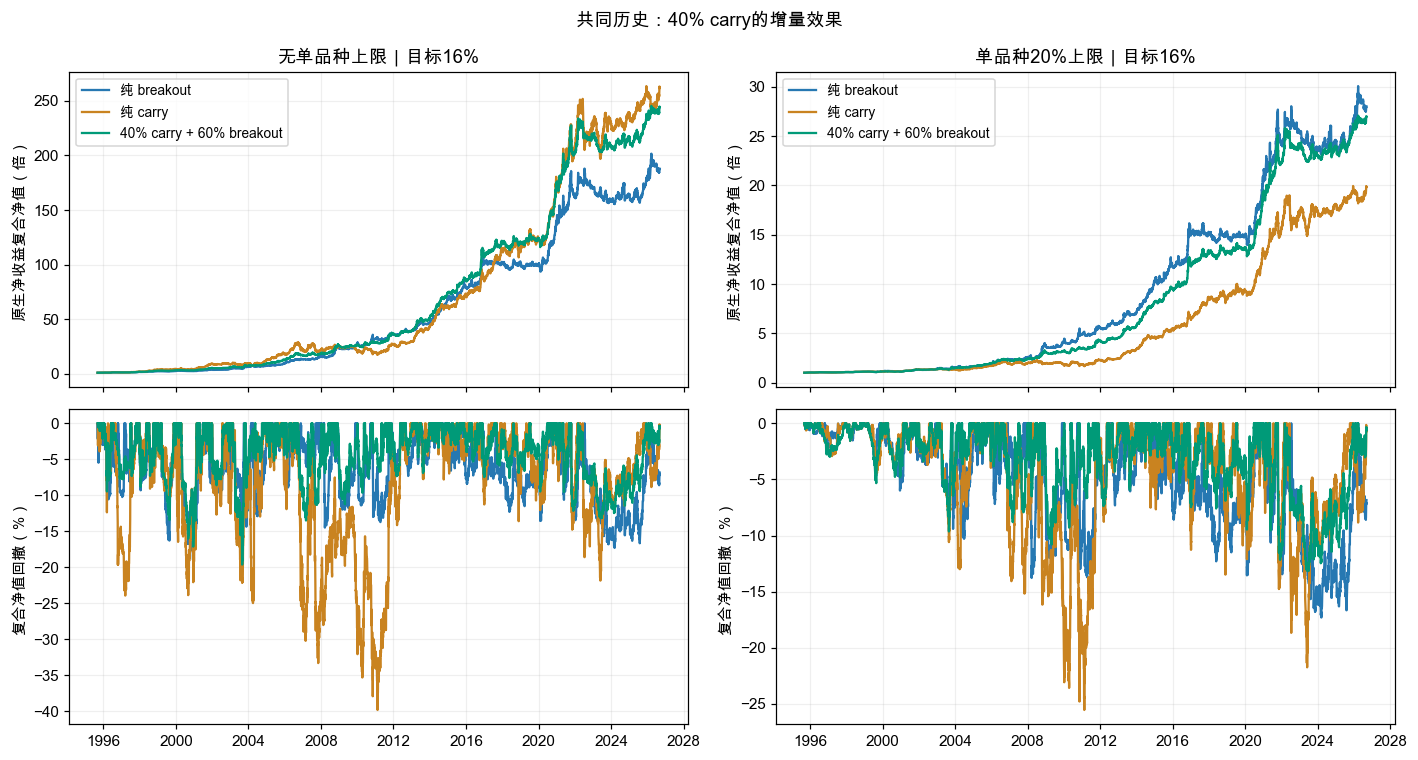

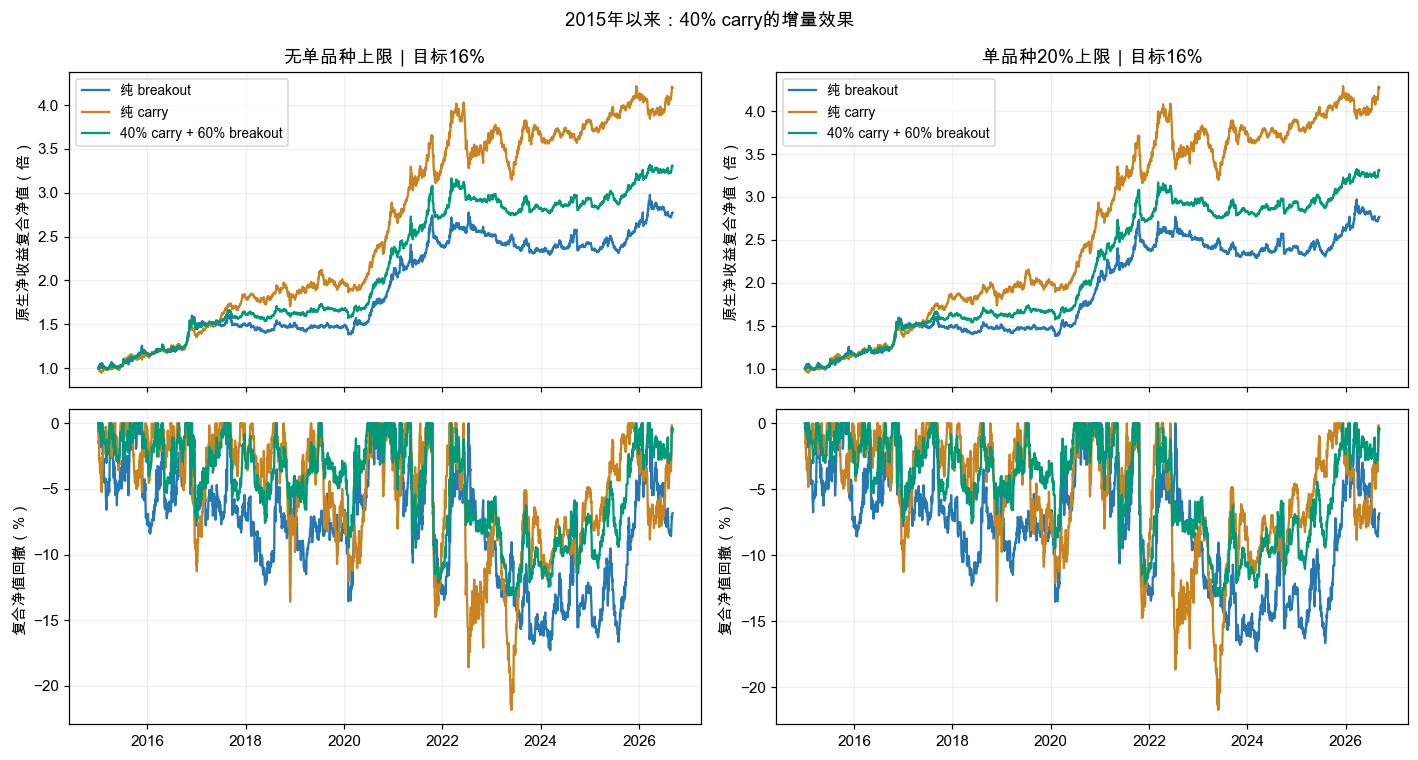

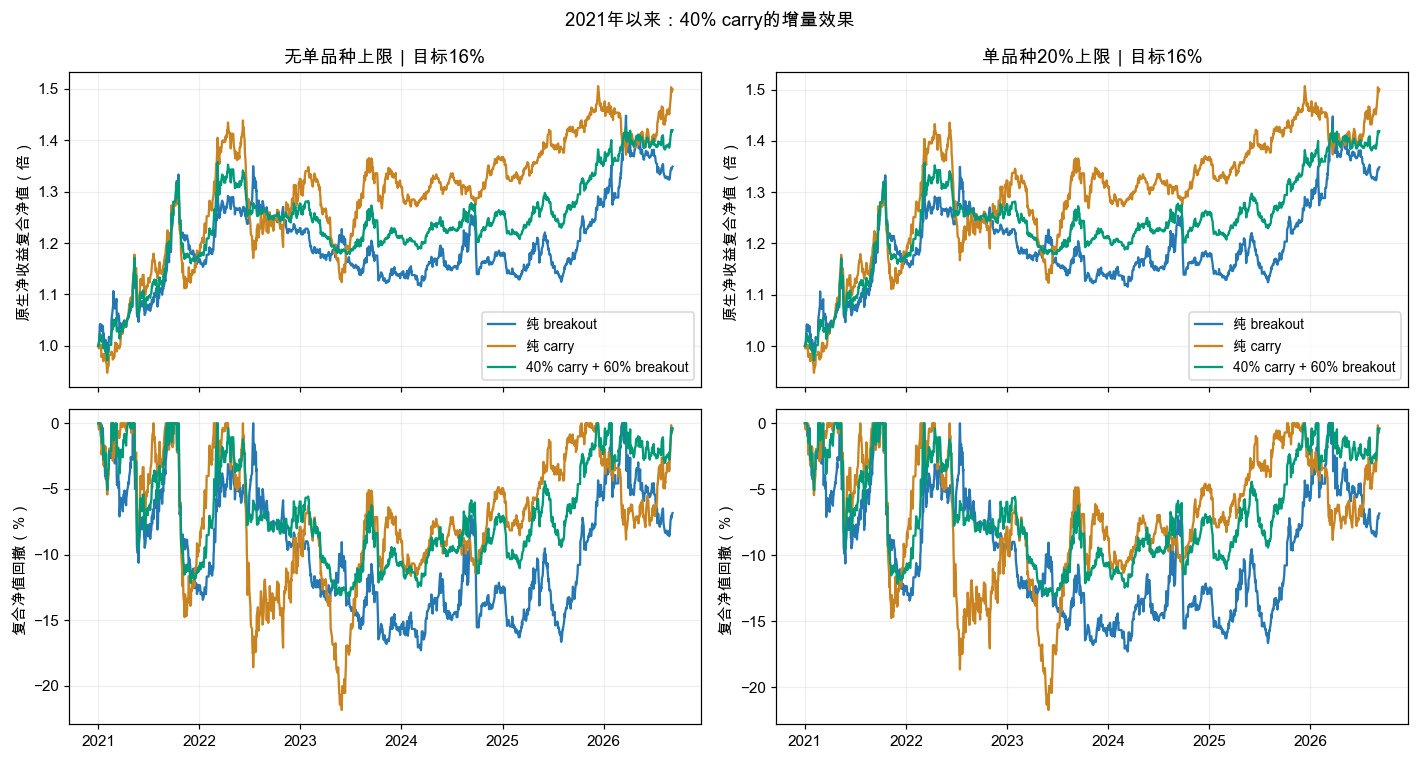

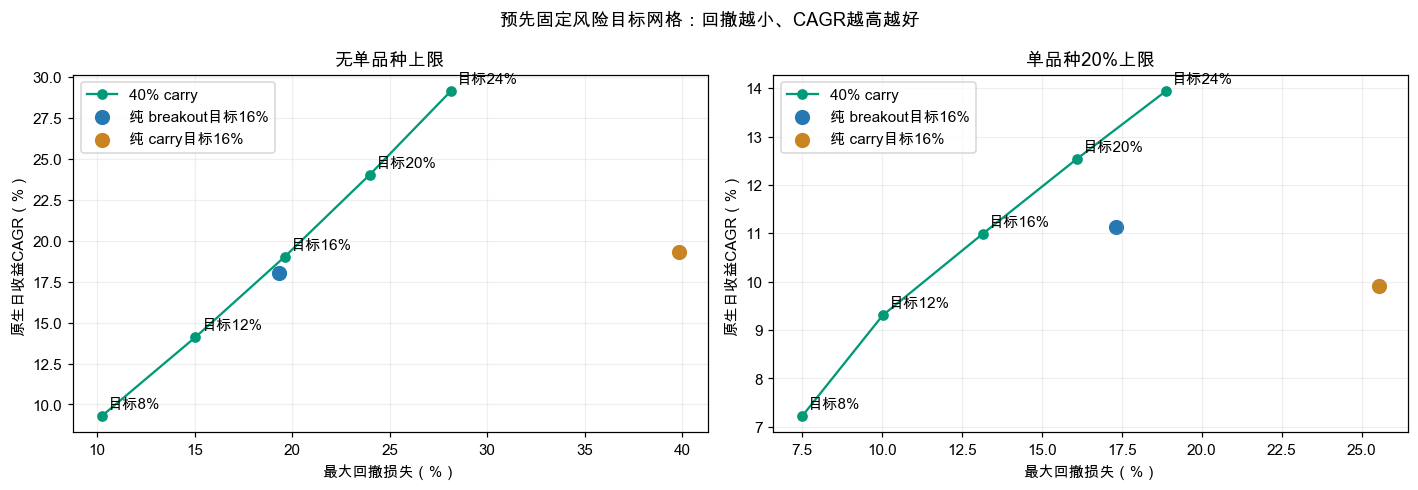

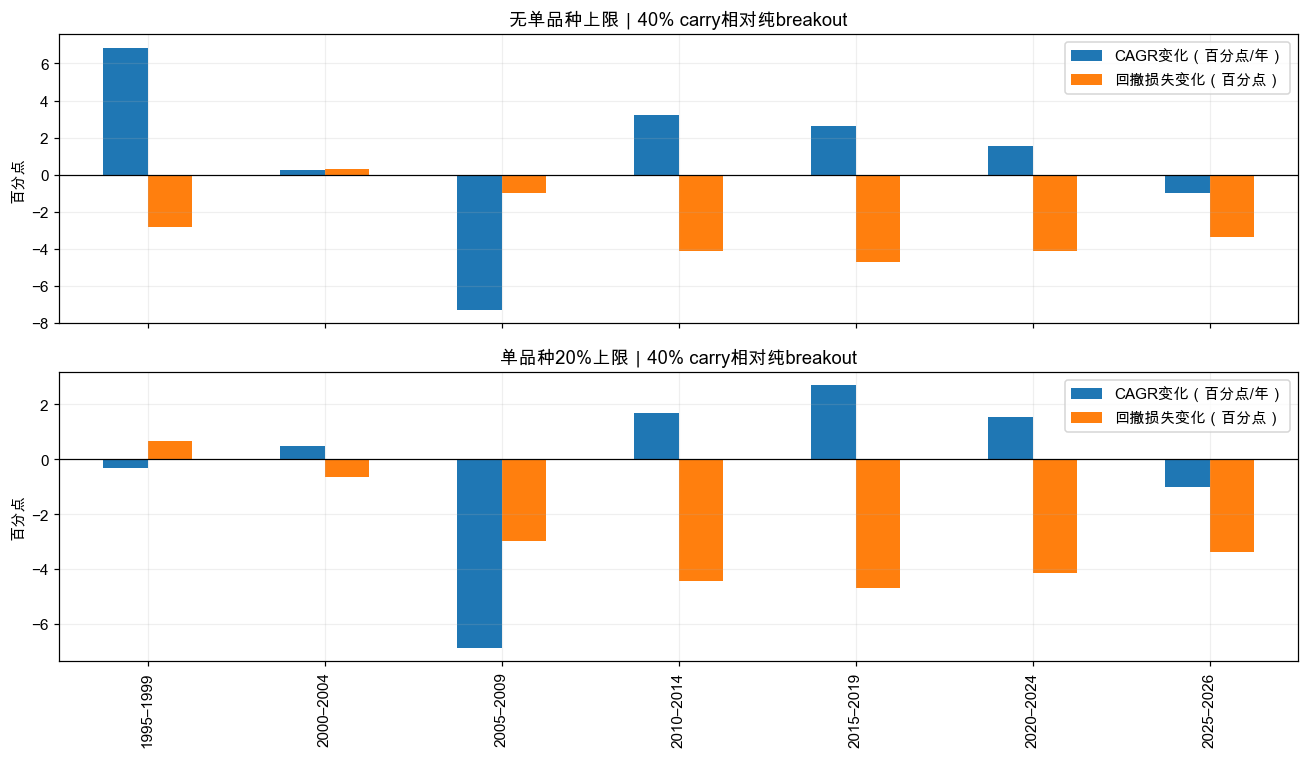

In [12]:
COLORS = {'breakout':'#2678b2','carry':'#c98320','mixed40':'#009a78'}
for period in ['共同历史','2015年以来','2021年以来']:
    start,end = periods[period]
    fig, axes = plt.subplots(2,2,figsize=(13,7),sharex='col')
    for col, cap in enumerate(CAPS):
        for case in CASES:
            f = results[(case,cap,16.)].loc[start:end]
            wealth = (1+f.net_pct/100).cumprod()
            dd = 100*(wealth/wealth.cummax().clip(lower=1)-1)
            axes[0,col].plot(wealth.index,wealth,label=LABELS[case],color=COLORS[case])
            axes[1,col].plot(dd.index,dd,color=COLORS[case])
        axes[0,col].set_title(CAP_LABELS[cap]+'｜目标16%')
        axes[0,col].set_ylabel('原生净收益复合净值（倍）')
        axes[1,col].set_ylabel('复合净值回撤（%）')
        axes[0,col].legend(fontsize=9)
    fig.suptitle(period+'：40% carry的增量效果')
    fig.tight_layout()
    fig.savefig(RUN_ROOT/'figures'/f'wealth_{period}.png')
    plt.show()
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
for ax,cap in zip(axes,CAPS):
    points = grid.loc[grid.cap.eq(cap)].sort_values('target')
    ax.plot(points.max_dd,points.cagr,'o-',color=COLORS['mixed40'],label='40% carry')
    for row in points.itertuples():
        ax.annotate(f'目标{row.target:g}%',(row.max_dd,row.cagr),xytext=(4,5),textcoords='offset points')
    for case in ['breakout','carry']:
        row = baseline.loc[(cap,case)]
        ax.scatter(row.max_dd,row.cagr,s=80,color=COLORS[case],label=LABELS[case]+'目标16%')
    ax.set(title=CAP_LABELS[cap],xlabel='最大回撤损失（%）',ylabel='原生日收益CAGR（%）')
    ax.legend()
fig.suptitle('预先固定风险目标网格：回撤越小、CAGR越高越好')
fig.tight_layout()
fig.savefig(RUN_ROOT/'figures'/'risk_grid.png')
plt.show()
fig, axes = plt.subplots(2,1,figsize=(12,7),sharex=True)
five = changes.loc[changes.strategy.eq('mixed40') & changes.period.str.contains('–')]
for ax,cap in zip(axes,CAPS):
    part = five.loc[five.cap.eq(cap)].set_index('period')
    part[['cagr_change_pp','drawdown_change_pp']].rename(columns={
        'cagr_change_pp':'CAGR变化（百分点/年）','drawdown_change_pp':'回撤损失变化（百分点）'}).plot.bar(ax=ax)
    ax.axhline(0,color='black',lw=.8)
    ax.set(title=CAP_LABELS[cap]+'｜40% carry相对纯breakout',ylabel='百分点',xlabel='')
fig.tight_layout()
fig.savefig(RUN_ROOT/'figures'/'five_year_increment.png')
plt.show()


## 增量来自哪些品种

两档限额各自展示纯breakout与40%混合之间的逐品种净收益贡献变化。贡献统一除以当日原生组合资金，以百分点表示。

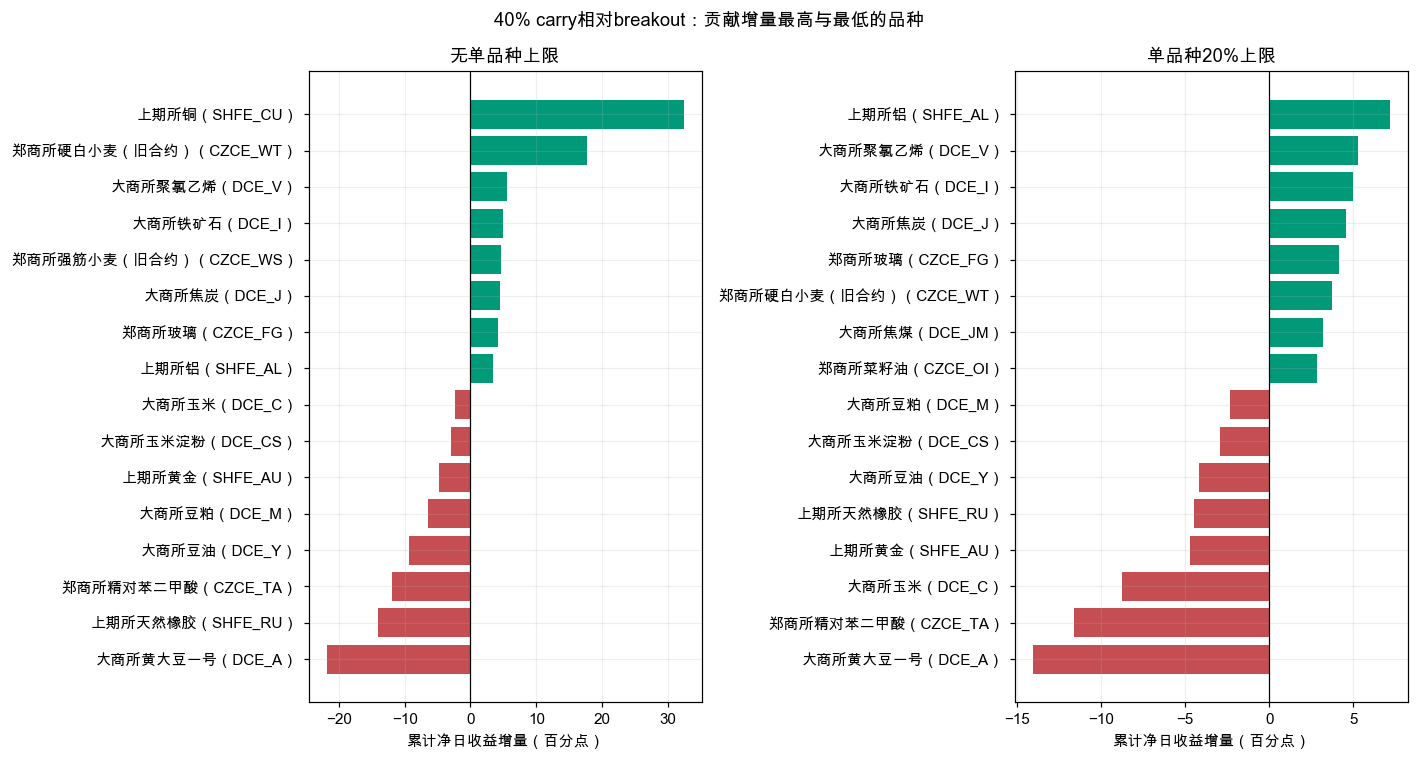

贡献为累计日收益百分点；复利CAGR由组合整体计算。


In [13]:
# 单品种贡献采用组合统一资金分母；其和精确等于组合的原生净日收益。
contribution_rows = []
for cap in CAPS:
    for period in ['共同历史','2015年以来','2021年以来']:
        start,end = periods[period]
        for code in eligible_codes:
            values = {}
            for case in CASES:
                part = detail[(case,cap)].xs(code,level='instrument')
                port = results[(case,cap,16.)]
                values[case] = (100*part.net_cnh/port.capital).loc[start:end].sum()
            contribution_rows.append(dict(cap=cap,period=period,instrument=code,
                description=metadata.loc[code,'Description'],**values,
                increment_pp=values['mixed40']-values['breakout']))
contribution = pd.DataFrame(contribution_rows)
contribution.to_csv(RUN_ROOT/'instrument_increment.csv',index=False)
fig,axes = plt.subplots(1,2,figsize=(13,7))
for ax,cap in zip(axes,CAPS):
    part = contribution.loc[contribution.cap.eq(cap)&contribution.period.eq('共同历史')].sort_values('increment_pp')
    shown = pd.concat([part.head(8),part.tail(8)])
    labels = shown.description+'（'+shown.instrument+'）'
    ax.barh(labels,shown.increment_pp,color=np.where(shown.increment_pp.ge(0),'#009a78','#c44e52'))
    ax.axvline(0,color='black',lw=.8)
    ax.set(title=CAP_LABELS[cap],xlabel='累计净日收益增量（百分点）')
fig.suptitle('40% carry相对breakout：贡献增量最高与最低的品种')
fig.tight_layout()
fig.savefig(RUN_ROOT/'figures'/'instrument_increment.png')
plt.show()
print('贡献为累计日收益百分点；复利CAGR由组合整体计算。')


## 成交容量与费用边界

基准资金为1亿元，并使用全复利。20%单品种名义上限仍需要成交容量核验。下表比较原生订单相对滞后成交量的比例，作为加入carry后的执行代价诊断。

In [14]:
volume = pd.read_parquet(DATA_ROOT/'volume_diagnostics.parquet')
capacity_rows = []
for (case,cap), wide in detail.items():
    for code in eligible_codes:
        part = wide.xs(code,level='instrument')
        evidence = volume.xs(code,level='instrument')
        prior = evidence.contract_volume_prior_mean20.reindex(part.index)
        old_prior = evidence.contract_volume_prior_mean20.shift(1).reindex(part.index)
        chain = evidence.price_contract.reindex(part.index).ffill()
        roll = chain.ne(chain.shift()) & chain.notna() & chain.shift().notna()
        new_order = (part.order-part.held).abs().where(~roll,part.order.abs())
        old_exit = part.held.abs().where(roll,0.)
        ratio = pd.concat([new_order/prior.where(prior.gt(0)),
                          old_exit/old_prior.where(old_prior.gt(0))],axis=1).max(axis=1)
        unknown = (new_order.gt(0)&~prior.gt(0)) | (old_exit.gt(0)&~old_prior.gt(0))
        ratio = ratio.mask(unknown)
        valid = market[code].observed.reindex(part.index).fillna(False) & results[(case,cap,16.)].normal
        trade = valid & (new_order+old_exit).gt(0)
        holding = valid & part.held.ne(0)
        capacity_rows.append(dict(strategy=case,cap=cap,instrument=code,
            order_days=int(trade.sum()),over10_days=int((trade&ratio.gt(.10)).sum()),
            unknown_days=int((trade&unknown).sum()),order_ratio_p95=ratio.loc[trade].quantile(.95),
            holding_adv_days_p95=(part.held.abs()/prior.where(prior.gt(0))).loc[holding].quantile(.95)))
capacity = pd.DataFrame(capacity_rows)
capacity.to_csv(RUN_ROOT/'capacity.csv',index=False)
display(capacity.groupby(['cap','strategy'])[['order_days','over10_days','unknown_days']].sum())
display(capacity.query("strategy == 'mixed40' and cap == 'cap20'").sort_values('order_ratio_p95',ascending=False).head(10))
print('成交量参考同合约滞后20个实际观察均量；订单含换月两腿，取更高比例。')
print('原生成本模型未按参与率放大滑点；1亿元起始、全复利历史的容量限制需单独处理。')


order_days  over10_days  unknown_days
cap       strategy                                       
cap20     breakout      109829         3136           289
          carry          77283         2405           215
          mixed40        95122         2693           258
unlimited breakout      115457        10178           399
          carry          87626        10406           330
          mixed40       101690         9324           364

,strategy,cap,instrument,order_days,over10_days,unknown_days,order_ratio_p95,holding_adv_days_p95
473,mixed40,cap20,CZCE_RS,22,22,0,99.057,30.882
484,mixed40,cap20,CZCE_WT,390,161,0,34.678,29.439
482,mixed40,cap20,CZCE_WH,696,249,0,8.478,15.773
494,mixed40,cap20,DCE_FB,884,567,0,3.518,25.047
461,mixed40,cap20,CZCE_LR,27,17,0,2.995,2.652
507,mixed40,cap20,DCE_RR,875,462,0,2.684,9.151
470,mixed40,cap20,CZCE_RI,56,11,0,2.123,3.434
538,mixed40,cap20,SHFE_WR,96,35,0,0.462,2.457
495,mixed40,cap20,DCE_FB_OLD,175,20,0,0.376,5.084
488,mixed40,cap20,DCE_BB,66,21,0,0.303,5.016


成交量参考同合约滞后20个实际观察均量；订单含换月两腿，取更高比例。
原生成本模型未按参与率放大滑点；1亿元起始、全复利历史的容量限制需单独处理。


## CAGR差异的样本敏感性

用固定种子的2000次配对年度区块抽样，观察40%混合相对纯breakout的CAGR变化区间。每次三策略使用相同年份；这项统计只反映已观察收益的变动，无法消除事后数据审理影响。

In [15]:
# 配对年度区块抽样：同一次抽样给三策略使用相同年份，保留年内日收益。
# 这是原生日收益差异的抽样敏感性，原生交易路径保持既有计算结果。
rng = np.random.default_rng(20260907)
bootstrap_rows = []
for cap in CAPS:
    for period in ['共同历史','2015年以来','2021年以来']:
        start,end = periods[period]
        r = pd.concat({case:results[(case,cap,16.)].net_pct/100 for case in CASES},axis=1).loc[start:end]
        if r.empty:
            continue
        logs = np.log1p(r).groupby(r.index.year).sum()
        counts = r.groupby(r.index.year).size()
        sample = rng.integers(0,len(logs),size=(2000,len(logs)))
        annual_logs = logs.to_numpy()[sample].sum(axis=1)*ANNUAL_DAYS/counts.to_numpy()[sample].sum(axis=1)[:,None]
        cagr_sample = 100*np.expm1(annual_logs)
        difference = cagr_sample[:,2]-cagr_sample[:,0]
        bootstrap_rows.append(dict(cap=cap,period=period,year_blocks=len(logs),
            delta_cagr_low=np.quantile(difference,.025),delta_cagr_high=np.quantile(difference,.975),
            positive_fraction=(difference>0).mean()))
bootstrap = pd.DataFrame(bootstrap_rows)
bootstrap.to_csv(RUN_ROOT/'paired_year_bootstrap.csv',index=False)
display(bootstrap)
print('年度区块抽样区间不覆盖数据审核偏差与模型风险；2021年以来年份较少，区间仅作敏感性说明。')


,cap,period,year_blocks,delta_cagr_low,delta_cagr_high,positive_fraction
0,unlimited,共同历史,32,-1.792,3.867,0.761
1,unlimited,2015年以来,12,-0.316,3.829,0.948
2,unlimited,2021年以来,6,-0.396,2.117,0.915
3,cap20,共同历史,32,-1.865,1.544,0.440
4,cap20,2015年以来,12,-0.306,4.061,0.945
5,cap20,2021年以来,6,-0.364,2.157,0.916


年度区块抽样区间不覆盖数据审核偏差与模型风险；2021年以来年份较少，区间仅作敏感性说明。


In [17]:
import json
assert len(results)==14 and len(detail)==6
assert all(set(w).issubset(RULES) and np.isclose(sum(w.values()),1) for w in WEIGHTS.values())
assert np.isclose(sum(v for k,v in WEIGHTS['mixed40'].items() if k.startswith('carry')),.4)
assert BASE_CONFIG['volatility_calculation']['backfill'] is False
assert len(eligible_codes)==90
assert all(f.index.max()<=CUTOFF for f in results.values())
assert pd.DataFrame(run_rows).failure.isna().all()
assert all(hashlib.sha256(Path(p).read_bytes()).hexdigest()==h for p,h in input_hashes.items())
for code in eligible_codes:
    for _, segment in market[code].groupby('window'):
        assert pd.isna(segment.returns.iloc[0])
        assert raw_rule_frames[code].loc[segment.index].iloc[:19].breakout40.isna().all()
for (case,cap),wide in detail.items():
    pnl = wide.net_cnh.groupby(level='date').sum()
    port = results[(case,cap,16.)]
    contribution_sum = 100*pnl/port.capital
    np.testing.assert_allclose(contribution_sum.loc[common_start:common_end],
                               port.net_pct.loc[common_start:common_end],atol=1e-9)
# 首日亏损必须进入复利净值回撤；子区间原生账户不可吞掉首日收益。
probe = pd.Series([-10.,10.],index=pd.bdate_range('2020-01-01',periods=2))
a = accountCurve(pandlCalculationWithoutPositions(probe,probe*0,100.),is_percentage=True)
pd.testing.assert_series_equal(a.as_ts,probe,check_names=False)
w = (1+a.as_ts/100).cumprod()
assert np.isclose((w/w.cummax().clip(lower=1)-1).min(),-.10)
receipt = {'cutoff':AS_OF,'capital_cnh':CAPITAL,'systems':len(results),
           'instruments':len(eligible_codes),'common_start':str(common_start.date()),
           'common_end':str(common_end.date()),'account_failures':0,
           'baseline_daily_reconciliations':4,'annualisation_business_days':ANNUAL_DAYS,
           'pnl_cost_reconciliation':'passed','delay_and_zero_gap_positions':'passed',
           'decision_caps':'passed','native_first_return':'passed','input_hashes':'unchanged'}
(RUN_ROOT/'validation.json').write_text(json.dumps(receipt,ensure_ascii=False,indent=2))
display(pd.Series(receipt).to_frame('结果'))


,结果
cutoff,2026-09-07
capital_cnh,"100,000,000.000"
systems,14
instruments,90
common_start,1995-09-06
common_end,2026-09-07
account_failures,0
baseline_daily_reconciliations,4
annualisation_business_days,256.000
pnl_cost_reconciliation,passed


## 结论：加入carry的价值与幅度

**这份回测支持把40% carry作为breakout的分散来源。最清楚的改善是Sharpe与回撤；CAGR增厚取决于敞口限制和时期。** 以下均为1亿元初始资金、1995-09-06至2026-09-07共同历史，CAGR使用原生复利账户净日收益、256业务日年化。

| 同16%目标 | 纯breakout CAGR | 40% carry CAGR | CAGR变化 | Sharpe变化 | 最大回撤变化 |
|---|---:|---:|---:|---:|---:|
| 无单品种上限 | 18.02% | 19.01% | **+0.99个百分点/年**（相对+5.48%） | 1.35→1.60 | 19.32%→19.62% |
| 单品种20%上限 | 11.12% | 10.99% | **−0.13个百分点/年**（相对−1.20%） | 1.11→1.35 | 17.31%→13.16% |

20%上限下，长期CAGR基本持平，最大回撤缩小**4.15个百分点**。实际年化波动从10.00%降至7.96%；无上限时从12.90%降至11.26%。固定FDM=1时，信号抵消会降低混合forecast幅度，16%的参数值与实际组合波动之间存在差距。

**回撤相近时的收益空间。** 单品种上限仍为20%，将混合目标设为20%：CAGR为**12.54%**，较breakout16提高**1.42个百分点/年**；回撤16.10%，Sharpe1.30，实际波动9.41%。混合目标24%：CAGR为**13.95%**，提高**2.82个百分点/年**；回撤18.89%，Sharpe1.26，实际波动10.79%。两点满足回撤相差不超过2个百分点、Sharpe降幅不超过0.10。这是预设网格中的**全历史事后匹配**，收益提升同时包含提高风险目标的影响。24%目标在2005–2009年的CAGR仍比breakout16低5.82个百分点/年；网格优势有时期依赖。

所有混合网格点的Sharpe均比breakout基准高出0.10以上，因此严格的“Sharpe±0.10且回撤±2个百分点”双重相近条件没有满足点。满足回撤条件的案例拥有更高的样本Sharpe。

**纯carry对照。** 无上限时，混合与纯carry的CAGR分别为19.01%和19.28%，回撤为19.62%和39.81%，Sharpe为1.60和1.15。20%上限下，混合CAGR比纯carry高1.07个百分点/年，回撤少12.39个百分点。混合的风险收益权衡更适合本次“为breakout增加一个来源”的研究问题。

**稳定性。** 20%上限、固定16%目标：2015年以来CAGR由8.92%升至10.58%（+1.66个百分点/年）；2021年以来由5.30%升至6.23%（+0.93）。2005–2009年由20.71%降至13.83%；2025年至截止日由8.16%降至7.13%。七个固定分段中，混合CAGR高于breakout的区间有4个；无上限时有5个。2025–2026段包含2026年截至9月7日的数据。

**回撤期间的实际帮助。** 20%上限下，breakout从2022-07-15峰值至2024-03-12谷底损失17.31%，同期混合损失6.91%，纯carry盈利10.16%。无上限的2003年回撤阶段，混合亏损19.62%，breakout亏损15.87%；carry也会放大某些亏损阶段。全历史两家族日收益相关性为0.13（20%上限）和0.20（无上限），提供了分散的来源。40%是forecast权重，实际风险贡献会随价格、信号、相关性和限仓变化。

**费用与容量。** 固定16%目标下，混合年化成本由breakout的0.584%降至0.533%（无上限），20%上限下由0.363%降至0.295%。20%上限的混合仍有2693个“品种×订单日”的订单超过参考均量10%，另有258个订单日的成交量为零或未知；油菜籽、旧硬麦、强麦、纤维板等历史片段容量较弱。原生成本尚未按成交参与率放大滑点，本金和复利增长对执行的影响需要计入采用判断。

**CAGR增厚的确定性有限。** 配对年度抽样的95%区间：无上限增量为−1.79至+3.87个百分点/年，20%上限为−1.87至+1.54。区间均跨零；数据有效区间与低波动筛选也使用了全历史信息。因此，当前最有依据的采用理由是改善breakout的风险收益效率，并为未来的风险预算调整提供空间。固定16%、40% carry的主对照可作为继续验证的基线。

原生资金乘数口径也得到相近结论：无上限CAGR为18.15%→19.13%；20%上限为11.15%→11.02%。现金权益和原生累计收益百分点回撤已分别列出，便于核对。

14个System均正常；四个纯策略基准逐日复现当前1亿元报告。逐品种盈亏及成本加总、延迟成交、区间空仓、下单上限、首日收益和冻结输入哈希检查通过。结果与六张线性图保存于 `private/research_runs/carry_breakout_native_2026-09-07/carry40_comparison`。